In [1]:
# import modules

import numpy as np
import geopandas as gpd
import pandas as pd
import osmnx as ox
from shapely.geometry import shape, box, Point, Polygon, LineString, MultiLineString, MultiPolygon

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import branca.colormap as cm

import h3

import folium
from folium import plugins

import requests
import math

import base64
from io import BytesIO
from IPython.display import display

### Input Variables

In [9]:
# specify city
city_name = input('Enter city name: ')
print(city_name)
#specify mode of transport
mot = input('Enter mode of transport (foot-walking,cycling-regular): ')
if mot == "foot-walking":
    print("Successfully chose walking mode.")
elif mot == "cycling-regular":
    print("Successfully chose biking mode.")
else:
    print("ERROR, please enter a correct mode of transport")
timeframe = input('Enter timeframe (5, 10, 15, 20)')
print(f"Successfully chose {timeframe} minutes timeframe.")
speed = input('Enter speed options (normal, elderly, toddlers) (HINT: Normal = 5 km/h, Elderly 3.3km/h, Toddlers = 2.5km/h): ')
if speed == "normal":
    print("Successfully chose normal speed.")
elif speed == "elderly":
    print("Successfully chose elderly speed.")
elif speed == "toddlers":
    print("Successfully chose toddler speed.")
else:
    print("ERROR, please enter a correct mode of transport")

Friedrichshafen, Germany
Successfully chose walking mode.
Successfully chose 15 minutes timeframe.
Successfully chose normal speed.


## City Polygon

<Axes: >

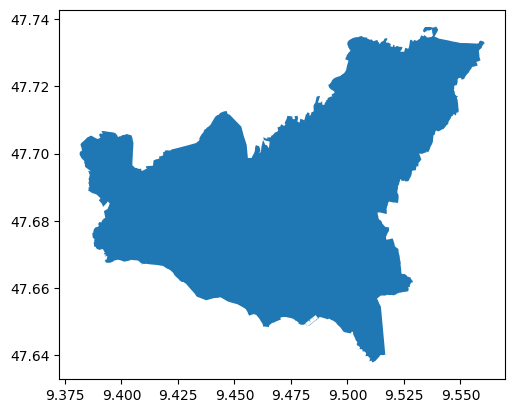

In [10]:
# Option 1.1 osmnx

PLACE_NAME = city_name
graph=ox.graph_from_place(PLACE_NAME)
# Get geometry for the place a geodataframe
city_polygon = ox.geocode_to_gdf(PLACE_NAME)
#plot the area
city_polygon.plot()

### Bounding Box for POIs

Original Bounding Box (Projected): 528623.9091312925, 5276170.877991708, 542041.4014044778, 5287307.327386162
Buffered Bounding Box (Projected): 527123.9091312925, 5274670.877991708, 543541.4014044778, 5288807.327386162


<Axes: >

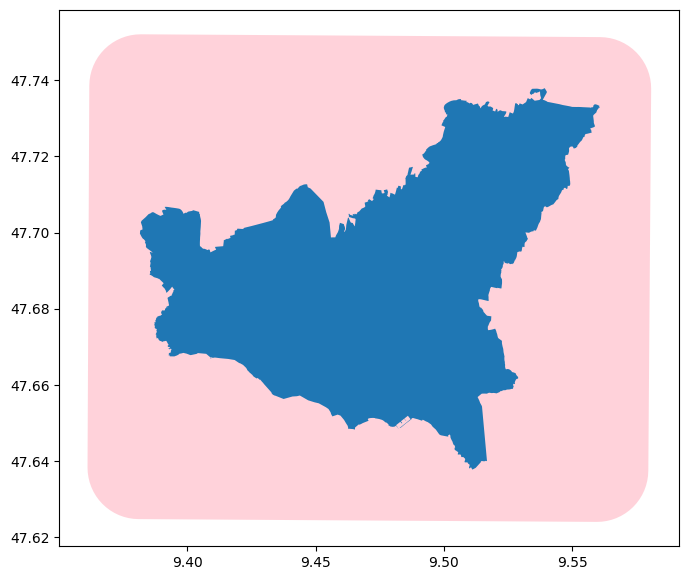

In [11]:
# reproject to metric
city_polygon_projected = city_polygon.to_crs(epsg=32632)  # UTM Zone 32N

# Get the total bounds of the reprjected city
minx, miny, maxx, maxy = city_polygon_projected.total_bounds

# Print the original bounding box
print(f"Original Bounding Box (Projected): {minx}, {miny}, {maxx}, {maxy}")

# Create a Polygon from the bounding box
bounding_box = box(minx, miny, maxx, maxy)

# Buffer the polygon by 1.5 km (1500 meters)
if mot == 'foot-walking':
    buffer_distance = 1500  # anticipating walking distance in 15min
else:
    buffer_distance = 3750 # anticipating biking distance in 15 min (15km/h)
buffered_bbox = bounding_box.buffer(buffer_distance)

# Get the bounds of the buffered polygon
buffered_minx, buffered_miny, buffered_maxx, buffered_maxy = buffered_bbox.bounds

# Print the new buffered bounding box
print(f"Buffered Bounding Box (Projected): {buffered_minx}, {buffered_miny}, {buffered_maxx}, {buffered_maxy}")

# reproject to 4326
buffered_bbox_gdf = gpd.GeoDataFrame(geometry=[buffered_bbox], crs="EPSG:32632")
buffered_bbox_gdf = buffered_bbox_gdf.to_crs(epsg=4326)

# Get the bounds in the original CRS
minx, miny, maxx, maxy = buffered_bbox_gdf.total_bounds

fig, ax = plt.subplots(figsize=(8, 8))
buffered_bbox_gdf.plot(ax=ax, alpha=0.7, color="pink")
city_polygon.plot(ax=ax)

### Fetch POIs

In [12]:
# Categories

commerce = {
    'shop': ['supermarket', 'convenience', 'bakery', 'grocery'],
    'amenity': ['marketplace', 'bank', 'post_box', 'atm', 'post_office']
}

healthcare = {
    'amenity': ['pharmacy', 'doctors', 'dentist', 'hospital', 'clinic'],
    'leisure': ['park', 'garden', 'fitness_centre', 'fitness_station', 'playground', 'sports_centre'],
    'landuse': ['recreation_ground', 'forest'],
    'club': ['sport'],
}

education = {
    'amenity': ['kindergarten', 'childcare', 'school']
}

entertainment = {
    'amenity': ['restaurant', 'fast_food', 'café', 'bar', 'pub', 'ice_cream', 'night_club', 'biergarten', 'library', 'theatre', 'museum', 'cinema', 'arts_centre', 'community_centre', 'events_venue'],
    'sport': ['swimming']
}

# Query all  within the bounding box
def get_pois_gdf(tags):
    pois = ox.geometries_from_bbox(north=maxy, south=miny, east=maxx, west=minx, tags=tags)
    gdf = gpd.GeoDataFrame(pois, crs="EPSG:4326")
    gdf.set_geometry('geometry', crs="EPSG:4326")
    return gdf

# Define tag dictionaries for each category
categories = {
    "commerce": commerce,
    "healthcare": healthcare,
    "education": education,
    "entertainment": entertainment
}

# Create a GeoDataFrame for each category and assign it to a variable with the format category_gdf
for category, tags in categories.items():
    globals()[f"{category}_gdf"] = get_pois_gdf(tags)

/var/folders/0h/0ncvw0p13k9g0x96c9qgwv4h0000gn/T/ipykernel_83755/1107479777.py:26: FutureWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in the v2.0.0 release. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  pois = ox.geometries_from_bbox(north=maxy, south=miny, east=maxx, west=minx, tags=tags)
/Users/milenalang/anaconda3/envs/tsa2/lib/python3.11/site-packages/osmnx/geometries.py:48: FutureWarning: The `north`, `south`, `east`, and `west` parameters are deprecated and will be removed in the v2.0.0 release. Use the `bbox` parameter instead. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  return features.features_from_bbox(north, south, east, west, tags=tags)
/var/folders/0h/0ncvw0p13k9g0x96c9qgwv4h0000gn/T/ipykernel_83755/1107479777.py:

### Convert POIs to Points

In [13]:
# Convert everything to a point
def geometry_to_single_point(geometry):
    """
    Converts a geometry to a single representative point

    Returns: All POIs as Points
    """
    if geometry.geom_type == 'Point':
        return geometry
    elif geometry.geom_type == 'LineString':
        midpoint = geometry.interpolate(0.5, normalized=True)
        return Point(midpoint)
    elif geometry.geom_type == 'Polygon':
        return geometry.centroid
    elif geometry.geom_type == 'MultiPolygon':
        # Choose the centroid of the largest polygon within the MultiPolygon
        largest_polygon = max(geometry.geoms, key=lambda p: p.area)
        return largest_polygon.centroid
    elif geometry.geom_type == 'MultiLineString':
        # Choose the midpoint of the longest line within the MultiLineString
        longest_line = max(geometry.geoms, key=lambda l: l.length)
        midpoint = longest_line.interpolate(0.5, normalized=True)
        return Point(midpoint)
    else:
        return None

def gdf_to_single_points_with_attributes(gdf):
    """
    Convert a GeoDataFrame to a GeoDataFrame of single representative points while retaining all attributes.

    Returns: GDF with all attributes
    """
    gdf['geometry'] = gdf.geometry.apply(geometry_to_single_point)
    return gdf

healthcare_gdf = gdf_to_single_points_with_attributes(healthcare_gdf)
commerce_gdf = gdf_to_single_points_with_attributes(commerce_gdf)
education_gdf = gdf_to_single_points_with_attributes(education_gdf)
entertainment_gdf = gdf_to_single_points_with_attributes(entertainment_gdf)

In [14]:
# Convert complex column types (e.g., lists, dicts) to strings
for col in healthcare_gdf.columns:
    if healthcare_gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
        healthcare_gdf[col] = healthcare_gdf[col].apply(lambda x: str(x) if isinstance(x, (list, dict)) else x)

healthcare_gdf.to_file("healthcare.geojson", driver="GeoJSON")


for col in commerce_gdf.columns:
    if commerce_gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
        commerce_gdf[col] = commerce_gdf[col].apply(lambda x: str(x) if isinstance(x, (list, dict)) else x)

commerce_gdf.to_file("commerce.geojson", driver="GeoJSON")


for col in education_gdf.columns:
    if education_gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
        education_gdf[col] = education_gdf[col].apply(lambda x: str(x) if isinstance(x, (list, dict)) else x)

education_gdf.to_file("education.geojson", driver="GeoJSON")


for col in entertainment_gdf.columns:
    if entertainment_gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
        entertainment_gdf[col] = entertainment_gdf[col].apply(lambda x: str(x) if isinstance(x, (list, dict)) else x)

entertainment_gdf.to_file("entertainment.geojson", driver="GeoJSON")

### Create H3 Hexagons

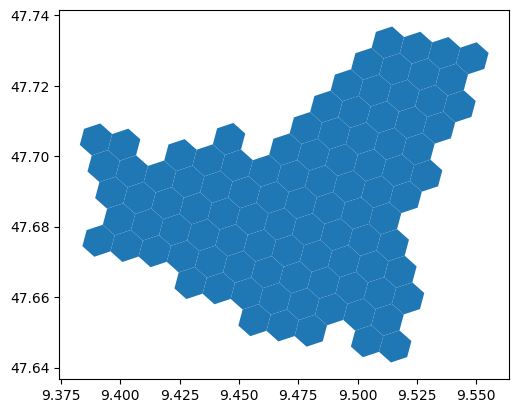

,geometry,hex_id
0,"POLYGON ((9.42998 47.68064, 9.42818 47.67610, ...",881f8e8ed9fffff
1,"POLYGON ((9.44613 47.64285, 9.44433 47.63830, ...",881f8e8ebbfffff
2,"POLYGON ((9.54978 47.71568, 9.54798 47.71114, ...",881f8e84b5fffff
3,"POLYGON ((9.40518 47.71235, 9.40339 47.70780, ...",881f8e850bfffff
4,"POLYGON ((9.50230 47.72165, 9.50049 47.71711, ...",881f8e85dbfffff


In [15]:
# Get the total bounds of the GeoDataFrame (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = city_polygon.total_bounds

# Set the  H3 resolution (finer resolution means smaller hexagons)
resolution = 8

# Generate H3 hexagons covering the bounding box
hexagons = h3.polyfill(
    {
        "type": "Polygon",
        "coordinates": [
            [
                [minx, miny],
                [maxx, miny],
                [maxx, maxy],
                [minx, maxy],
                [minx, miny],
            ]
        ],
    },
    resolution,
    geo_json_conformant=True,
)
# Convert hexagons to GeoJSON features with hex_id
hexagon_features = [
    {
        "type": "Feature",
        "properties": {"hex_id": hex_id},
        "geometry": {
            "type": "Polygon",
            "coordinates": [h3.h3_to_geo_boundary(hex_id, geo_json=True)],
        },
    }
    for hex_id in hexagons
]

# Create a GeoDataFrame from the features
hexagons_gdf = gpd.GeoDataFrame.from_features(hexagon_features, crs="EPSG:4326")


# Ensure city_polygon is a unary union of the city boundary geometries if there are multiple polygons
city_union = city_polygon.unary_union

# Function to calculate the intersection area ratio of each hexagon within the city boundary
def area_ratio_within_city(hexagon, city_union):
    # Calculate the intersection of the hexagon with the city boundary
    intersection = hexagon.intersection(city_union)
    # Calculate the area ratio (intersection area / hexagon area)
    return intersection.area / hexagon.area if hexagon.area > 0 else 0

# Apply the function to each hexagon in the GeoDataFrame and filter for those with at least 60% inside the city
hexagons_within_intersect = hexagons_gdf[hexagons_gdf.geometry.apply(area_ratio_within_city, city_union=city_union) >= 0.4]

# Now hexagons_within_intersect contains only those hexagons with at least 60% of their area within the city boundary

# Plot the result to verify
hexagons_within_intersect.plot()
plt.show()


hexagons_gdf.head()

### Filter hexagons for those with population

In [ ]:
# Read zensus file
zensus = gpd.read_file('zensus_germany.gpkg')

# Use overlay to calculate overlapping area
intersection_gdf = gpd.overlay(hexagons_within_intersect, zensus, how='intersection')

# Calculate area of overlap for each intersection
intersection_gdf['overlap_area'] = intersection_gdf.area

# Calculate the total overlap area for each hexagon
total_overlap_area = intersection_gdf.groupby('hex_id')['overlap_area'].sum().reset_index()
total_overlap_area.rename(columns={'overlap_area': 'total_overlap_area'}, inplace=True)

# Merge total overlap area back into the intersection_gdf
intersection_gdf = intersection_gdf.merge(total_overlap_area, on='hex_id')

# Calculate the proportion of each overlap area relative to the total overlap area
intersection_gdf['area_weight'] = intersection_gdf['overlap_area'] / intersection_gdf['total_overlap_area']

# Calculate the area-weighted population contribution for each intersection
intersection_gdf['weighted_population'] = intersection_gdf['area_weight'] * intersection_gdf['Einwohner']

# Sum the weighted populations to get the total population for each hexagon
population_by_hex = intersection_gdf.groupby('hex_id')['weighted_population'].sum().reset_index()
population_by_hex.rename(columns={'weighted_population': 'Einwohner'}, inplace=True)

# Merge the calculated population back into the hexagons dataframe
hexagons_with_population = hexagons_within_intersect.merge(population_by_hex, on='hex_id', how='left')

# Filter out hexagons with no inhabitants
hexagons_with_population = hexagons_with_population[
    (hexagons_with_population['Einwohner'].notnull()) & (hexagons_with_population['Einwohner'] != 0)
]

# Plot the hexagons with their population
hexagons_with_population.plot(column='Einwohner', legend=True)

# Extract the centers of each hexagon for visualization or further analysis
centers = []
for hex_id in hexagons_with_population['hex_id']:
    center_lat, center_lng = h3.h3_to_geo(hex_id)
    centers.append((center_lat, center_lng))

# Create a list of Point geometries from the centers
geometry = [Point(lon, lat) for lat, lon in centers]

# Create a GeoDataFrame with the center points
centers_gdf = gpd.GeoDataFrame(geometry=geometry, crs="EPSG:4326")

#### Create Coordinate Arrays

In [12]:
# Convert each category's GeoDataFrame to a NumPy array of coordinates
center_coordinates = np.array([(geom.x, geom.y) for geom in centers_gdf.geometry])
commerce_coordinates = np.array([(geom.x, geom.y) for geom in commerce_gdf.geometry])
healthcare_coordinates = np.array([(geom.x, geom.y) for geom in healthcare_gdf.geometry])
education_coordinates = np.array([(geom.x, geom.y) for geom in education_gdf.geometry])
entertainment_coordinates = np.array([(geom.x, geom.y) for geom in entertainment_gdf.geometry])


### Population Density as Living Indicator

<Axes: >

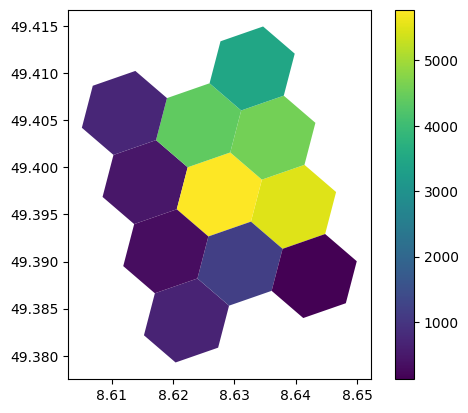

In [13]:
# create living indicator from population density
hexagons_with_population['population_density'] = hexagons_with_population['Einwohner']
hexagons_with_population['Living'] = hexagons_with_population['Einwohner']
hexagons_with_population['Living'] = hexagons_with_population['Living'].fillna(0)
hexagons_with_population.plot(column='Living', legend=True)

### Batch processing of distance matrix

In [14]:
# Define the fixed batch size
fixed_batch_size = 10
timeframe = int(timeframe)

#set speeds for each population group
speeds = {
    "normal": 1.3889,    # 5 km/h in m/s
    "elderly": 0.9167,   # 3.3 km/h in m/s
    "toddlers": 0.6944   # 2.5 km/h in m/s
}

def get_time_from_timeframe(timeframe, speed):
    """
    calculates the walkspeed for each population group
    """
    if timeframe not in [5, 10, 15, 20]:
        raise ValueError("Unsupported timeframe. Supported values are 5, 10, 15, 20.")

    if speed not in speeds:
        raise ValueError("Unsupported speed type. Supported values are 'normal', 'elderly', 'toddlers'.")

    base_time = timeframe * 60  #convert minutes to seconds
    return base_time * (speeds[speed] / speeds["normal"])

def process_batch(center_coords, category_coords, start_idx, end_idx, time):
    """
    calculates time matrices for fixed batch size
    """

    # Select the batch of category points
    batch_coords = category_coords[start_idx:end_idx]
    all_coordinates = np.vstack([center_coords, batch_coords]).tolist()

    # Define the request body
    body = {
        "locations": all_coordinates,
        "metrics": ["duration"]
    }

    headers = {
        'Accept': 'application/json, application/geo+json, application/gpx+xml, img/png; charset=utf-8',
        'Authorization': 'YOUR_API_KEY',
        'Content-Type': 'application/json; charset=utf-8'
    }

    # Construct the URL dynamically using the mot variable
    url = f'http://localhost:8080/ors/v2/matrix/{mot}'

    # Send the POST request to the ORS API with the dynamic URL
    response = requests.post(url, json=body, headers=headers)
    data = response.json()
    print(data)

    # Extract the duration matrix
    durations = data.get('durations', [])
    num_category_points = len(batch_coords)

    # Extract relevant part of the duration matrix (centers to batch points)
    relevant_durations = [row[-num_category_points:] for row in durations[:len(center_coords)]]

    # Extract reachable points
    reachable_points = []
    for i, row in enumerate(relevant_durations):
        for j, duration in enumerate(row):
            if duration is not None and duration <= time:  # Check if duration is not None and within the calculated time
                reachable_points.append((i, start_idx + j))  # Store index of center and category point

    return relevant_durations, reachable_points


def process_category(category_name, category_coords, timeframe):
    """
    calculates the duration matrices for a category
    """
    num_centers = len(center_coordinates)
    total_points = len(category_coords)
    num_batches = math.ceil(total_points / fixed_batch_size)

    # Calculate the time based on the given timeframe
    time = get_time_from_timeframe(timeframe,speed)

    print(f"Category: {category_name}")
    print(f"Number of Centers: {num_centers}")
    print(f"Total Points: {total_points}")
    print(f"Fixed Batch Size: {fixed_batch_size}")
    print(f"Number of Batches: {num_batches}")

    results = pd.DataFrame(0, index=[f"Center {i+1}" for i in range(num_centers)], columns=[category_name])
    all_reachable_points = []

    for batch_idx in range(num_batches):
        start_idx = batch_idx * fixed_batch_size
        end_idx = min(start_idx + fixed_batch_size, total_points)

        print(f"Processing {category_name} Batch {batch_idx + 1}/{num_batches}...")
        print(f"Start Index: {start_idx}, End Index: {end_idx}")

        # Process the current batch
        batch_durations, batch_reachable_points = process_batch(center_coordinates, category_coords, start_idx, end_idx, time)

        # Update reachable points list
        all_reachable_points.extend(batch_reachable_points)

        # Create a DataFrame for the batch
        batch_df = pd.DataFrame(batch_durations, columns=[f"{category_name} {i+1}" for i in range(start_idx, end_idx)], index=[f"Center {i+1}" for i in range(num_centers)])
        batch_filtered = batch_df[batch_df <= time].dropna(axis=1, how='all')
        reachable_counts = (batch_filtered <= time).sum(axis=1)
        results[category_name] += reachable_counts

    return results, all_reachable_points

# Dictionary to hold the coordinates of each category
categories = {
    "Commerce": commerce_coordinates,
    "Healthcare": healthcare_coordinates,
    "Education": education_coordinates,
    "Entertainment": entertainment_coordinates
}

final_results = pd.DataFrame(index=[f"Center {i+1}" for i in range(len(center_coordinates))])

for category_name, category_coords in categories.items():
    category_results, _ = process_category(category_name, category_coords, timeframe)
    final_results = pd.concat([final_results, category_results], axis=1, join='outer')

print(final_results)

Category: Commerce
Number of Centers: 11
Total Points: 106
Fixed Batch Size: 10
Number of Batches: 11
Processing Commerce Batch 1/11...
Start Index: 0, End Index: 10
{'metadata': {'attribution': 'openrouteservice.org, OpenStreetMap contributors', 'service': 'matrix', 'timestamp': 1736252016141, 'query': {'locations': [[8.639628842661013, 49.39581031102341], [8.615422880151023, 49.39843586187276], [8.627525682325517, 49.39712377259718], [8.636254539180657, 49.403154592254936], [8.622173893048588, 49.38374742114726], [8.630900431375476, 49.389779287859945], [8.643002521691468, 49.38846509430024], [8.624150308720864, 49.40446732177887], [8.632879611100435, 49.41049793785384], [8.618798698854548, 49.39109210924924], [8.612046436788129, 49.405778678876835], [8.6490409, 49.4242374], [8.6489063, 49.4235955], [8.6443664, 49.4249326], [8.5946939, 49.391722], [8.5980107, 49.392783], [8.5945719, 49.392355], [8.6627721, 49.418803], [8.6351296, 49.4036275], [8.6516592, 49.4199564], [8.633082, 49.40

In [15]:
##JOIN BACK
final_results.head()
# Convert center coordinates to hex ids
center_hex_ids = [h3.geo_to_h3(lat, lon, resolution) for lon, lat in center_coordinates]

# Add hex ids to the results DataFrame
final_results['hex_id'] = center_hex_ids

# Merge results with hexagon GeoDataFrame
hex_counts_df = hexagons_gdf.merge(final_results, left_on='hex_id', right_on='hex_id')
hex_counts_df = hex_counts_df.merge(
    hexagons_with_population[['hex_id', 'population_density', 'Living']],  # Only take the columns you need
    on='hex_id',  # Join on 'hex_id'
    how='left'  # Use 'left' join to keep all rows in original gdf
)
hex_counts_df.head()

,geometry,hex_id,Commerce,Healthcare,Education,Entertainment,population_density,Living
0,"POLYGON ((8.63447 49.39870, 8.63268 49.39424, ...",881faad649fffff,8,32.0,9,12.0,5492.437088,5492.437088
1,"POLYGON ((8.61026 49.40132, 8.60848 49.39686, ...",881fae6ca5fffff,3,18.0,1,9.0,456.425424,456.425424
2,"POLYGON ((8.62237 49.40001, 8.62058 49.39555, ...",881fae6ca7fffff,19,69.0,14,27.0,5777.057277,5777.057277
3,"POLYGON ((8.63109 49.40604, 8.62931 49.40158, ...",881fae6ca3fffff,24,83.0,14,27.0,4567.151057,4567.151057
4,"POLYGON ((8.61702 49.38663, 8.61523 49.38217, ...",881fae6d93fffff,0,6.0,0,2.0,670.735225,670.735225


### Score Calculation

In [16]:
# Define benchmarks
benchmarks = {
    'Commerce': 5,
    'Healthcare': 5,
    'Education': 5,
    'Entertainment': 20,
    'Living': 2000
}

# Function to normalize category scores
def normalize_score(value, benchmark):
    """
    Computes ratio between actual value and benchmark, scales to 0-100, ensures limit of 100
    """
    if benchmark == 0:
        return 0  # Or return a specific value indicating no comparison can be made
    return min((value / benchmark) * 100, 100)

# Calculate normalized scores for each category
for category, benchmark in benchmarks.items():
    hex_counts_df[f'{category}_normalized'] = hex_counts_df[category].apply(lambda x: normalize_score(x, benchmark))

# List of normalized score columns
normalized_columns = [f'{category}_normalized' for category in benchmarks.keys()]

# Calculate the average score over all columns
hex_counts_df['score'] = hex_counts_df[normalized_columns].mean(axis=1)

## WEIGHTED SCORE
if speed == 'elderly':
    weights = {
        'Living': 0.1,
        'Commerce': 0.3,
        'Healthcare': 0.35,
        'Education': 0.05,
        'Entertainment': 0.2
    }
elif speed == 'normal':
    weights = {
        'Living': 0.1,
        'Commerce': 0.3,
        'Healthcare': 0.35,
        'Education': 0.05,
        'Entertainment': 0.2
    }
elif speed == 'toddlers':
    weights = {
        'Living': 0.2,
        'Commerce': 0.1,
        'Healthcare': 0.3,
        'Education': 0.3,
        'Entertainment': 0.1
    }

hex_counts_df['weighted_score'] = sum(
    hex_counts_df[f'{category}_normalized'] * weight
    for category, weight in weights.items()
)
hex_counts_df.head()

,geometry,hex_id,Commerce,Healthcare,Education,Entertainment,population_density,Living,Commerce_normalized,Healthcare_normalized,Education_normalized,Entertainment_normalized,Living_normalized,score,weighted_score
0,"POLYGON ((8.63447 49.39870, 8.63268 49.39424, ...",881faad649fffff,8,32.0,9,12.0,5492.437088,5492.437088,100.0,100,100.0,60.0,100.000000,92.000000,92.000000
1,"POLYGON ((8.61026 49.40132, 8.60848 49.39686, ...",881fae6ca5fffff,3,18.0,1,9.0,456.425424,456.425424,60.0,100,20.0,45.0,22.821271,49.564254,65.282127
2,"POLYGON ((8.62237 49.40001, 8.62058 49.39555, ...",881fae6ca7fffff,19,69.0,14,27.0,5777.057277,5777.057277,100.0,100,100.0,100.0,100.000000,100.000000,100.000000
3,"POLYGON ((8.63109 49.40604, 8.62931 49.40158, ...",881fae6ca3fffff,24,83.0,14,27.0,4567.151057,4567.151057,100.0,100,100.0,100.0,100.000000,100.000000,100.000000
4,"POLYGON ((8.61702 49.38663, 8.61523 49.38217, ...",881fae6d93fffff,0,6.0,0,2.0,670.735225,670.735225,0.0,100,0.0,10.0,33.536761,28.707352,40.353676


In [29]:
### OPTIONAL SAVE
# Save the dataframe to GeoJSON
hex_counts_df.to_file(f"{city_name}_{mot}_{timeframe}_{speed}_final.geojson", driver='GeoJSON')

### Radar Chart

In [35]:
def create_radar_chart(categories, values, filename):
    """
    creates a radar chart for the number of reachable POIs per category across all hexagons
    """
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop

    values += values[:1]  # Complete the loop

    fig, ax = plt.subplots(figsize=(3, 3), subplot_kw=dict(polar=True))  # Smaller figure size
    ax.fill(angles, values, color='blue', alpha=0.25)
    ax.plot(angles, values, color='blue', linewidth=2)

    ax.set_yticklabels([])  # Remove radial labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    # Adding numbers to the radar chart
    for i, (angle, value) in enumerate(zip(angles[:-1], values[:-1])):
        ax.text(angle, value, f'{value:.1f}', horizontalalignment='center', verticalalignment='center')

    plt.savefig(filename, bbox_inches='tight', pad_inches=0.1)  # Adjust padding if needed
    plt.close()


def get_image_base64(filename):
    with open(filename, "rb") as img_file:
        return base64.b64encode(img_file.read()).decode('utf-8')

def add_radar_chart_to_map(m, hexagon_data):
    # Calculate averages for each category
    categories = ['Commerce', 'Healthcare', 'Education', 'Entertainment']
    averages = {category: hexagon_data[category].mean() for category in categories}

    # Create radar chart
    radar_chart_filename = "average_radar_chart.png"
    create_radar_chart(categories, [averages[category] for category in categories], radar_chart_filename)

    # Convert radar chart to base64
    image_base64 = get_image_base64(radar_chart_filename)
    img_html = f'<img src="data:image/png;base64,{image_base64}" style="width: 200px; height: 200px;">'

    # Create a HTML to embed radar chart in the left middle of the map
    custom_html = f'''
    <div style="
        position: fixed;
        left: 20px; top: 50%; transform: translateY(-50%);
        width: 220px; height: 250px;
        background-color: white;
        border: 2px solid grey; z-index: 9999; font-size: 12px;
        padding: 5px;
        box-shadow: 0px 0px 10px rgba(0,0,0,0.5);
        ">
        <b>Average POIs per Category across Hexagons</b><br>
        {img_html}
    </div>
    '''

    # Add to the map
    m.get_root().html.add_child(folium.Element(custom_html))


### Visualisation

In [36]:
# create color map from matplotlib (red to blue) for overall score
colormap = mpl.colormaps['bwr_r']
norm = mcolors.Normalize(vmin=0, vmax=100)

# Function to convert a score to a color
def score_to_color(score):
    rgba_color = colormap(norm(score))
    return mcolors.to_hex(rgba_color)

# Initialize Folium map around the region
m = folium.Map(location=[center_coordinates[:, 1].mean(), center_coordinates[:, 0].mean()],
               tiles="cartodbpositron", zoom_start=12, control_scale=True)

# Create a feature group for the overall score hexagons
score_hexagon_layer = folium.FeatureGroup(name='Score Hexagons')


# Add hexagons and markers to the feature group
def add_hexagons_and_markers_to_layer(gdf):
    for _, row in gdf.iterrows():
        geom = row['geometry']
        if geom.geom_type == 'Polygon':
            coords = [(lat, lon) for lon, lat in list(geom.exterior.coords)]  # Convert to (lat, lon) format

            # Determine the color based on the score
            hex_color = score_to_color(row['score'])

            # Create popup message with scores for each category and the final score
            popup_content = "<br>".join([f"{category}: {round(row[category], 1)}" for category in benchmarks.keys()])
            popup_content += f"<br><b>Unweighted Score: {row['score']:.1f}</b>"
            popup_content += f"<br><b>Weighted Score: {row['weighted_score']:.1f}</b>"

            # Add the polygon to the hexagon layer
            folium.Polygon(
                locations=coords,
                color="black",
                fill=True,
                fill_color=hex_color,
                fill_opacity=0.1,
                weight=0.5,
                popup=popup_content
            ).add_to(score_hexagon_layer)

            # Calculate the centroid for the label
            centroid = geom.centroid
            centroid_lat = centroid.y
            centroid_lon = centroid.x

            # Add a marker with the score at the centroid
            folium.Marker(
                location=[centroid_lat, centroid_lon],
                icon=folium.DivIcon(
                    html=f'<div style="font-size: 10px; color: black; text-align: center;">{row["weighted_score"]:.0f}</div>'
                )
            ).add_to(score_hexagon_layer)

# Add hexagons and markers to the feature group
add_hexagons_and_markers_to_layer(hex_counts_df)

# Add the score hexagon layer to the map
score_hexagon_layer.add_to(m)

# Create color map for residential percentage ()
residential_color_map = cm.LinearColormap(['white', 'darkblue'], vmin=0, vmax=hex_counts_df['Living'].max())

# Add feature group for the residential buildings percentage
residential_layer = folium.FeatureGroup(name='Population Density [People/km²]', show=False)

# Function to add hexagons for residential percentage to the map
def add_residential_hexagons(gdf):
    for _, row in gdf.iterrows():
        geom = row['geometry']
        if geom.geom_type == 'Polygon':
            coords = [(lat, lon) for lon, lat in list(geom.exterior.coords)]  # Convert to (lat, lon) format

            # Determine the color based on the residential percentage
            residential_color = residential_color_map(row['Living'])

            # Create a popup message with the residential percentage
            popup_content = f"{row['Living']:.1f} People/km²%"

            # Add the polygon to the residential layer
            folium.Polygon(
                locations=coords,
                color="black",
                fill=True,
                fill_color=residential_color,
                fill_opacity=0.7,
                weight=0.5,
                popup=popup_content
            ).add_to(residential_layer)

residential_layer.add_to(m)
add_residential_hexagons(hex_counts_df)


# Create color maps for each category (from white to dark blue)
color_maps = {
    category: cm.LinearColormap(['white', 'darkblue'], vmin=0, vmax=hex_counts_df[category].max())
    for category in benchmarks.keys()
}
# Add a color map for the share of residential buildings
color_maps['Living'] = cm.LinearColormap(['white', 'darkblue'], vmin=0, vmax=hex_counts_df['Living'].max())

# Function to add hexagons for each category to the map
def add_category_hexagons(gdf, category):
    # Check if the category is 'Living' and adjust the feature group name
    if category == 'Living':
        return

    hex_layer = folium.FeatureGroup(name=f'{category} Reachable POIs', show=False)  # Default for others

    for _, row in gdf.iterrows():
        geom = row['geometry']
        if geom.geom_type == 'Polygon':
            coords = [(lat, lon) for lon, lat in list(geom.exterior.coords)]

            # Get the number of reachable POIs and corresponding color
            poi_count = row[category]
            hex_color = color_maps[category](poi_count)

            # Create a popup message with the number of POIs
            popup_content = f"{category} POIs: {poi_count}"

            # Add the polygon to the hexagon layer
            folium.Polygon(
                locations=coords,
                color="black",
                fill=True,
                fill_color=hex_color,
                fill_opacity=0.7,
                weight=0.5,
                popup=popup_content
            ).add_to(hex_layer)

    hex_layer.add_to(m)

# Add hexagons for each category
for category in benchmarks.keys():
    add_category_hexagons(hex_counts_df, category)



# Define colors for each category
colors = {
    'Living': '#6495ED',         # Cornflower Blue
    'Commerce': '#9370DB',       # Medium Purple
    'Healthcare': '#FF6F61',     # Coral Red
    'Education': '#FFD700',      # Golden Yellow
    'Entertainment': '#2AAA8A'   # Dark Peach
}


# Function to plot POIs for a category with specific colors
def plot_pois(category_gdf, category_name, layer_group):
    for _, row in category_gdf.iterrows():
        # Attempt to get the 'name', 'amenity', 'leisure', and 'public_transport' attributes
        name = row.get('name')
        amenity = row.get('amenity')
        leisure = row.get('leisure')
        public_transport = row.get('public_transport')
        landuse = row.get('landuse')
        sport = row.get('sport')
        club = row.get('club')
        shop = row.get('shop')
        building = row.get('building')

        # Determine the content for the popup
        if pd.notna(name):  # Check if 'name' is not NaN
            popup_content = name
        elif pd.notna(amenity):  # Check if 'amenity' is not NaN
            popup_content = amenity
        elif pd.notna(leisure):  # Check if 'leisure' is not NaN
            popup_content = leisure
        elif pd.notna(public_transport):  # Check if 'public_transport' is not NaN
            popup_content = public_transport
        elif pd.notna(landuse):  # Check if 'landuse' is not NaN
            popup_content = landuse
        elif pd.notna(sport):  # Check if 'sport' is not NaN
            popup_content = sport
        elif pd.notna(club):  # Check if 'club' is not NaN
            popup_content = club
        elif pd.notna(shop):  # Check if 'shop' is not NaN
            popup_content = shop
        elif pd.notna(building):  # Check if 'building' is not NaN
            popup_content = building
        else:
            popup_content = 'Unknown'  # Fallback if all are NaN
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=2,  # Set radius to a small value for tiny dots
            color=colors[category_name],
            fill=True,
            fill_opacity=1.0,
            popup = popup_content
        ).add_to(layer_group)

# Add POIs as an extra layer in the final map
poi_layer = folium.FeatureGroup(name='Points of Interest', show=False)

# Plot each category of POIs on the map within the POI layer
#plot_pois(living_gdf, 'Living', poi_layer)
plot_pois(commerce_gdf, 'Commerce', poi_layer)
plot_pois(healthcare_gdf, 'Healthcare', poi_layer)
plot_pois(education_gdf, 'Education', poi_layer)
plot_pois(entertainment_gdf, 'Entertainment', poi_layer)

# Add the POI layer to the map
poi_layer.add_to(m)

# Add feature group for city polygon
city_boundaries = folium.FeatureGroup(name='Administrative Boundary', show=True)
def plot_polygons_on_map(gdf, feature_group, color, label):
    """
    Function to plot polygons (GeoDataFrame) on a Folium map.

    Parameters:
    - gdf: GeoDataFrame containing the polygon data
    - feature_group: Folium FeatureGroup to which polygons will be added
    - color: color to use for the polygon borders
    - label: label for the feature (shown in the legend)
    """
    folium.GeoJson(
        gdf,
        name=label,
        style_function=lambda x: {
            'fillColor': 'transparent',
            'color': color,
            'weight': 2,
            'opacity': 0.7
        }
    ).add_to(feature_group)
plot_polygons_on_map(city_polygon, city_boundaries, 'black', 'City Boundary')
city_boundaries.add_to(m)

# Define a color map for population count
colormap = cm.LinearColormap(['white', 'darkblue'])# Yellow to Red
norm = mcolors.Normalize(vmin=hex_counts_df['Living'].min(), vmax=hex_counts_df['Living'].max())

# Function to convert population count to color
def pop_to_color(pop_count):
    rgba_color = colormap(norm(pop_count))
    return mcolors.to_hex(rgba_color)

# Create a feature group for the population layer
population_layer = folium.FeatureGroup(name='Population Count', show=False)

# Add hexagons to the population layer
def add_population_hexagons(gdf):
    for _, row in gdf.iterrows():
        geom = row['geometry']
        if geom.geom_type == 'Polygon':
            coords = [(lat, lon) for lon, lat in list(geom.exterior.coords)]  # Convert to (lat, lon) format

            # Determine the color based on the population count
            hex_color = pop_to_color(row['Living'])

            # Create a popup message with the population count
            popup_content = f"Population: {row['Living']:.0f}"

            # Add the polygon to the population layer
            folium.Polygon(
                locations=coords,
                color="black",
                fill=True,
                fill_color=hex_color,
                fill_opacity=0.6,
                weight=0.5,
                popup=popup_content
            ).add_to(population_layer)

# Add hexagons to the population layer
add_population_hexagons(hex_counts_df)

# Add the population layer to the map
population_layer.add_to(m)


# add radar chart
add_radar_chart_to_map(m, hex_counts_df)


# Add the POI category legend to the map
def add_legend(map_obj, colors):
    legend_html = '''
    <div style="
        position: fixed;
        bottom: 70px; left: 20px; width: 180px; height: 120px;
        background-color: white;
        border:2px solid grey; z-index:9999; font-size:14px;
        ">
        &nbsp; <b>Category Legend</b> <br>
        &nbsp; Commerce &nbsp; <i class="fa fa-circle" style="color:{Commerce}"></i><br>
        &nbsp; Healthcare &nbsp; <i class="fa fa-circle" style="color:{Healthcare}"></i><br>
        &nbsp; Education &nbsp; <i class="fa fa-circle" style="color:{Education}"></i><br>
        &nbsp; Entertainment &nbsp; <i class="fa fa-circle" style="color:{Entertainment}"></i><br>
    </div>
    '''.format(**colors)  # Injecting the colors into the legend HTML

    map_obj.get_root().html.add_child(folium.Element(legend_html))

add_legend(m, colors)

def add_styled_legend(colormap, caption):
    colormap.caption = caption
    colormap.add_to(m)

    # Customize the legend's CSS style for a white background
    colormap.add_to(m).get_root().html.add_child(folium.Element(
        f"""
        <style>
            .legend {{
                background-color: white !important;
                padding: 5px;
                box-shadow: 0 0 5px rgba(0,0,0,0.3);
                border-radius: 5px;
            }}
        </style>
        """
    ))
# Create and add the overall score legend with white background
add_styled_legend(cm.LinearColormap(colors=['red', 'blue'], vmin=0, vmax=100), f"{timeframe}-Minute City {speed} {mot} Score (0 - 100)")

# Add legends for each category with white background
for category, cmap in color_maps.items():
    if category == 'Living':
        add_styled_legend(cmap, f"Population Density [People/km²]")
    else:
        add_styled_legend(cmap, f"{category} Reachable POIs")  # Default naming for others

# Add layer control to the map
folium.LayerControl().add_to(m)

# Add minimap to map
minimap = plugins.MiniMap(toggle_display=True, tile_layer="cartodbpositron")
m.add_child(minimap)

# Add full screen button to map
plugins.Fullscreen(position='topright').add_to(m)

# Display the map
#display(m)

# Save the map to an HTML file
m.save(f"{city_name}_{mot}_{timeframe}_{speed}_final.html")